In [1]:
"""
TSX Momentum Trading System
Author: Xiangru Mo
Date: March 2026
Strategy: S&P/TSX Composite Momentum (J=6, K=3)
Universe: S&P/TSX Composite Index (~220 stocks, .TO suffix on Yahoo Finance)
Benchmark: ^GSPTSE
"""

import pandas as pd
import numpy as np
import yfinance as yf
import requests
from io import StringIO
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-darkgrid')

print('=' * 80)
print('S&P/TSX COMPOSITE MOMENTUM TRADING SYSTEM')
print('=' * 80)
print(f'Initialized: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print()

S&P/TSX COMPOSITE MOMENTUM TRADING SYSTEM
Initialized: 2026-03-18 14:46:39



In [21]:
"""
CONFIGURATION
Same J=6, K=3 strategy — blended 50/50 universe of TSX and S&P 500 stocks.
Always holds 25 top-momentum TSX picks + 25 top-momentum S&P 500 picks.
"""

class Config:
    # Strategy Parameters
    lookback_months = 6
    holding_months  = 3
    skip_days       = 21

    # Portfolio split (constrained 50/50)
    n_tsx    = 10   # top momentum picks from S&P/TSX Composite
    n_sp500  = 10   # top momentum picks from S&P 500
    n_positions = n_tsx + n_sp500   # 50 total

    # Derived
    lookback_days  = lookback_months * 21
    holding_days   = holding_months  * 21
    rebalance_freq = 'QE'

    # Backtest
    start_date      = datetime.today() - relativedelta(years=20)
    end_date        = datetime.today()
    initial_capital = 100_000   # CAD

    # Market-specific
    universe         = 'S&P/TSX Composite (50%) + S&P 500 (50%)'
    benchmark_ticker = '^GSPTSE'
    risk_free_rate   = 0.03     # ~3% CAD (Bank of Canada)

    def __repr__(self):
        return (
            f'\nStrategy Configuration:\n'
            f'----------------------\n'
            f'Lookback Period (J): {self.lookback_months} months ({self.lookback_days} days)\n'
            f'Holding Period (K): {self.holding_months} months ({self.holding_days} days)\n'
            f'Skip Period: {self.skip_days} days\n'
            f'Portfolio Size: {self.n_positions} stocks '
            f'({self.n_tsx} TSX + {self.n_sp500} S&P 500, equal-weighted)\n'
            f'Rebalance Frequency: {self.rebalance_freq} (Quarterly)\n\n'
            f'Backtest Period: {self.start_date.strftime("%Y-%m-%d")} to {self.end_date.strftime("%Y-%m-%d")}\n'
            f'Initial Capital: ${self.initial_capital:,.0f} CAD\n'
            f'Universe: {self.universe}\n'
            f'Benchmark: {self.benchmark_ticker}\n'
            f'Risk-Free Rate: {self.risk_free_rate*100:.1f}% (Bank of Canada approx.)'
        )

config = Config()
print(config)


Strategy Configuration:
----------------------
Lookback Period (J): 6 months (126 days)
Holding Period (K): 3 months (63 days)
Skip Period: 21 days
Portfolio Size: 20 stocks (10 TSX + 10 S&P 500, equal-weighted)
Rebalance Frequency: QE (Quarterly)

Backtest Period: 2006-03-18 to 2026-03-18
Initial Capital: $100,000 CAD
Universe: S&P/TSX Composite (50%) + S&P 500 (50%)
Benchmark: ^GSPTSE
Risk-Free Rate: 3.0% (Bank of Canada approx.)


In [22]:
"""
DATA MODULE
Fetch tickers from Wikipedia for both universes.
Download price data separately, then merge for return calculation.
Note: Returns are calculated in local currency (CAD for TSX, USD for S&P 500).
      This is standard practice for multi-currency momentum — signals and equal-weighted
      returns are combined without FX conversion.
"""

def get_tsx_tickers():
    """Scrape S&P/TSX Composite tickers from Wikipedia with .TO suffix."""
    url = 'https://en.wikipedia.org/wiki/S%26P/TSX_Composite_Index'
    headers = {'User-Agent': 'Mozilla/5.0'}
    resp = requests.get(url, headers=headers, timeout=15)
    tables = pd.read_html(StringIO(resp.text))
    for table in tables:
        str_cols = {c: str(c).lower() for c in table.columns}
        if any(v in ['symbol', 'ticker', 'stock symbol'] for v in str_cols.values()):
            col = next(c for c, v in str_cols.items()
                       if v in ['symbol', 'ticker', 'stock symbol'])
            tickers = table[col].dropna().tolist()
            tickers = [
                str(t).strip() + '.TO'
                if not str(t).strip().endswith('.TO') else str(t).strip()
                for t in tickers
            ]
            print(f'✓ Retrieved {len(tickers)} S&P/TSX Composite tickers from Wikipedia')
            return tickers
    raise RuntimeError('Could not find ticker column in TSX Wikipedia table.')


def get_sp500_tickers():
    """Scrape S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    resp = requests.get(url, headers=headers, timeout=15)
    table = pd.read_html(StringIO(resp.text))[0]
    tickers = table['Symbol'].str.replace('.', '-', regex=False).tolist()
    print(f'✓ Retrieved {len(tickers)} S&P 500 tickers from Wikipedia')
    return tickers


def download_price_data(tickers, label, start_date, end_date):
    """Download adjusted close prices, drop stocks with >50% missing data."""
    print(f'\nDownloading {label} ({len(tickers)} tickers)...')
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=False, progress=True)
    adj_close = data['Adj Close']
    if isinstance(adj_close, pd.Series):
        adj_close = adj_close.to_frame()

    missing_pct = adj_close.isnull().sum() / len(adj_close) * 100
    bad = missing_pct[missing_pct > 50].index.tolist()
    if bad:
        print(f'⚠ Dropping {len(bad)} stocks with >50% missing data')
        adj_close = adj_close.drop(columns=bad)

    print(f'✓ {label}: {adj_close.shape[1]} stocks, {adj_close.shape[0]} days')
    return adj_close


print('=' * 80)
print('STEP 1: DATA ACQUISITION (TSX + S&P 500)')
print('=' * 80)

tsx_tickers   = get_tsx_tickers()
sp500_tickers = get_sp500_tickers()

adj_close_tsx   = download_price_data(tsx_tickers,   'TSX',     config.start_date, config.end_date)
adj_close_sp500 = download_price_data(sp500_tickers, 'S&P 500', config.start_date, config.end_date)

# Merge for return calculation — NaN where one market is closed, handled by .mean() later
adj_close_all = pd.concat([adj_close_tsx, adj_close_sp500], axis=1)
print(f'\n✓ Combined universe: {adj_close_all.shape[1]} stocks '
      f'({adj_close_tsx.shape[1]} TSX + {adj_close_sp500.shape[1]} S&P 500)')

STEP 1: DATA ACQUISITION (TSX + S&P 500)
✓ Retrieved 222 S&P/TSX Composite tickers from Wikipedia
✓ Retrieved 503 S&P 500 tickers from Wikipedia



[*                      3%                       ]  7 of 222 completed$CHP.UN.TO: possibly delisted; no timezone found
[**                     4%                       ]  8 of 222 completed$MEG.TO: possibly delisted; no timezone found
[****                   9%                       ]  19 of 222 completed$BEP.UN.TO: possibly delisted; no timezone found
[****                   9%                       ]  20 of 222 completed$CRT.UN.TO: possibly delisted; no timezone found
[****                   9%                       ]  21 of 222 completed$TCL.A.TO: possibly delisted; no timezone found
[*****                 10%                       ]  22 of 222 completed$CCL.B.TO: possibly delisted; no timezone found
[*******               14%                       ]  31 of 222 completed$CAR.UN.TO: possibly delisted; no timezone found
[*******               14%                       ]  32 of 222 completed$SRU.UN.TO: possibly delisted; no timezone found
[********              17%                     

⚠ Dropping 63 stocks with >50% missing data
✓ TSX: 159 stocks, 5019 days



[*********************100%***********************]  503 of 503 completed


⚠ Dropping 35 stocks with >50% missing data
✓ S&P 500: 468 stocks, 5031 days

✓ Combined universe: 627 stocks (159 TSX + 468 S&P 500)


In [23]:
"""
BENCHMARK
Download S&P/TSX Composite Index (^GSPTSE) for comparison.
"""

print('=' * 80)
print('STEP 2: BENCHMARK DATA (^GSPTSE)')
print('=' * 80)

bm_raw = yf.download(config.benchmark_ticker, start=config.start_date,
                     end=config.end_date, auto_adjust=True, progress=False)
benchmark_prices = bm_raw['Close'].squeeze()

print(f'✓ Benchmark: {len(benchmark_prices)} days')
print(f'Range: {benchmark_prices.index[0].strftime("%Y-%m-%d")} to {benchmark_prices.index[-1].strftime("%Y-%m-%d")}')

STEP 2: BENCHMARK DATA (^GSPTSE)
✓ Benchmark: 5019 days
Range: 2006-03-20 to 2026-03-18


In [24]:
"""
SIGNAL MODULE
Momentum = (P_{t-skip} / P_{t-lookback}) - 1
Identical to S&P 500 backtest logic.
"""

def calculate_momentum_scores(adj_close, date, lookback_days, skip_days):
    price_td = adj_close.loc[:date]
    if len(price_td) <= lookback_days:
        return pd.Series(dtype=float)
    p_lookback = price_td.iloc[-lookback_days]
    p_skip     = price_td.iloc[-skip_days]
    scores = (p_skip / p_lookback) - 1
    return scores.dropna().sort_values(ascending=False)


def form_portfolio(momentum_scores, n_positions):
    return momentum_scores.head(n_positions).index.tolist()


print('=' * 80)
print('STEP 3: SIGNAL MODULE LOADED')
print('=' * 80)
print('Formula: Momentum = (P_{t-21d} / P_{t-126d}) - 1')
print('✓ Ready')

STEP 3: SIGNAL MODULE LOADED
Formula: Momentum = (P_{t-21d} / P_{t-126d}) - 1
✓ Ready


In [25]:
"""
PORTFOLIO CONSTRUCTION
Constrained 50/50: pick top n_tsx from TSX and top n_sp500 from S&P 500 independently.
This guarantees geographic diversification regardless of market cycle.
"""

def generate_rebalance_dates(adj_close, frequency='QE'):
    rd = adj_close.resample(frequency).last()
    print(f'Generated {len(rd)} rebalance dates')
    print(f'First: {rd.index[0].strftime("%Y-%m-%d")}   Last: {rd.index[-1].strftime("%Y-%m-%d")}')
    return rd


def build_portfolios(adj_close_tsx, adj_close_sp500, rebalance_dates,
                     lookback_days, skip_days, n_tsx, n_sp500):
    portfolios = {}
    first_valid = max(adj_close_tsx.index[lookback_days], adj_close_sp500.index[lookback_days])
    valid_dates = rebalance_dates[rebalance_dates.index >= first_valid]
    print(f'Building portfolios for {len(valid_dates)} rebalance dates...')

    for i, date in enumerate(valid_dates.index):
        tsx_scores   = calculate_momentum_scores(adj_close_tsx,   date, lookback_days, skip_days)
        sp500_scores = calculate_momentum_scores(adj_close_sp500, date, lookback_days, skip_days)
        tsx_picks    = tsx_scores.head(n_tsx).index.tolist()
        sp500_picks  = sp500_scores.head(n_sp500).index.tolist()
        portfolios[date] = tsx_picks + sp500_picks

        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{len(valid_dates)} portfolios formed')

    print(f'\n✓ Built {len(portfolios)} portfolios ({n_tsx} TSX + {n_sp500} S&P 500 per period)')
    return portfolios


print('=' * 80)
print('STEP 4: PORTFOLIO CONSTRUCTION (50/50 TSX + S&P 500)')
print('=' * 80)

rebalance_dates = generate_rebalance_dates(adj_close_tsx, config.rebalance_freq)
portfolios = build_portfolios(adj_close_tsx, adj_close_sp500, rebalance_dates,
                              config.lookback_days, config.skip_days,
                              config.n_tsx, config.n_sp500)

last_date  = list(portfolios.keys())[-1]
tsx_part   = [t for t in portfolios[last_date] if t.endswith('.TO')]
sp500_part = [t for t in portfolios[last_date] if not t.endswith('.TO')]
print(f'\nMost recent portfolio ({last_date.strftime("%Y-%m-%d")}):')
print(f'  TSX picks ({len(tsx_part)}):    {tsx_part}')
print(f'  S&P 500 picks ({len(sp500_part)}): {sp500_part}')

STEP 4: PORTFOLIO CONSTRUCTION (50/50 TSX + S&P 500)
Generated 81 rebalance dates
First: 2006-03-31   Last: 2026-03-31
Building portfolios for 79 rebalance dates...
  10/79 portfolios formed
  20/79 portfolios formed
  30/79 portfolios formed
  40/79 portfolios formed
  50/79 portfolios formed
  60/79 portfolios formed
  70/79 portfolios formed

✓ Built 79 portfolios (10 TSX + 10 S&P 500 per period)

Most recent portfolio (2026-03-31):
  TSX picks (10):    ['AG.TO', 'LUN.TO', 'CG.TO', 'OGC.TO', 'CEU.TO', 'IMG.TO', 'HBM.TO', 'KNT.TO', 'DPM.TO', 'SII.TO']
  S&P 500 picks (10): ['WDC', 'TER', 'MU', 'CIEN', 'ALB', 'AMAT', 'STX', 'LRCX', 'INTC', 'FIX']


In [26]:
"""
BACKTEST EXECUTION
Equal-weighted period returns using the combined TSX + S&P 500 price data.
Each position contributes 1/50 of the portfolio regardless of currency.
"""

def calculate_portfolio_returns(adj_close, portfolios):
    results = []
    dates_list = list(portfolios.keys())
    print('Calculating portfolio returns...')

    for i, rd in enumerate(dates_list):
        holdings = portfolios[rd]
        next_rd  = dates_list[i + 1] if i < len(dates_list) - 1 else adj_close.index[-1]

        t0 = adj_close.index.asof(rd)
        t1 = adj_close.index.asof(next_rd)

        valid = [h for h in holdings if h in adj_close.columns]
        if not valid:
            continue

        ret = ((adj_close.loc[t1, valid] / adj_close.loc[t0, valid]) - 1).mean()
        results.append({'date': t1, 'return': ret})

        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{len(dates_list)} returns calculated')

    s = pd.Series([r['return'] for r in results], index=[r['date'] for r in results])
    print(f'\n✓ {len(s)} period returns calculated')
    return s


def benchmark_period_returns(benchmark_prices, portfolio_return_dates):
    bm_rets = []
    dates = portfolio_return_dates.index.tolist()
    for i in range(1, len(dates)):
        t0 = benchmark_prices.index.asof(dates[i-1])
        t1 = benchmark_prices.index.asof(dates[i])
        if pd.isna(t0) or pd.isna(t1):
            bm_rets.append(np.nan)
        else:
            bm_rets.append((benchmark_prices.loc[t1] / benchmark_prices.loc[t0]) - 1)
    return pd.Series(bm_rets, index=dates[1:])


print('=' * 80)
print('STEP 5: BACKTEST EXECUTION')
print('=' * 80)

portfolio_returns = calculate_portfolio_returns(adj_close_all, portfolios)
benchmark_returns = benchmark_period_returns(benchmark_prices, portfolio_returns)

common       = portfolio_returns.index.intersection(benchmark_returns.index)
port_aligned = portfolio_returns.loc[common]
bm_aligned   = benchmark_returns.loc[common]

cum     = (1 + portfolio_returns).cumprod()
n_years = len(portfolio_returns) / 4
total_ret = cum.iloc[-1] - 1
ann_ret   = (1 + total_ret) ** (1 / n_years) - 1

print(f"\n{'='*80}")
print('PRELIMINARY RESULTS')
print(f"{'='*80}")
print(f'Total Return:      {total_ret*100:.2f}%')
print(f'Annualized Return: {ann_ret*100:.2f}%')
print(f'Periods:           {len(portfolio_returns)}')
print(f"{'='*80}")

STEP 5: BACKTEST EXECUTION
Calculating portfolio returns...
  10/79 returns calculated
  20/79 returns calculated
  30/79 returns calculated
  40/79 returns calculated
  50/79 returns calculated
  60/79 returns calculated
  70/79 returns calculated

✓ 79 period returns calculated

PRELIMINARY RESULTS
Total Return:      nan%
Annualized Return: nan%
Periods:           79


In [28]:
"""
RISK METRICS
Full risk/return comparison: Blended Momentum vs TSX Composite benchmark.
"""

def risk_metrics(returns, label='Strategy', ppy=4, rfr=0.03):
    total   = (1 + returns).prod() - 1
    years   = len(returns) / ppy
    ann_ret = (1 + total) ** (1 / years) - 1
    ann_vol = returns.std() * np.sqrt(ppy)
    excess  = ann_ret - rfr
    sharpe  = excess / ann_vol if ann_vol else np.nan

    neg = returns[returns < 0]
    dd_dev  = neg.std() * np.sqrt(ppy) if len(neg) else np.nan
    sortino = excess / dd_dev if dd_dev else np.nan

    cum    = (1 + returns).cumprod()
    max_dd = ((cum - cum.expanding().max()) / cum.expanding().max()).min()
    calmar = ann_ret / abs(max_dd) if max_dd else np.nan
    win_rate = (returns > 0).mean()

    return {
        'Label':                label,
        'Total Return':         f'{total*100:.2f}%',
        'Annualized Return':    f'{ann_ret*100:.2f}%',
        'Annualized Volatility':f'{ann_vol*100:.2f}%',
        'Sharpe Ratio':         f'{sharpe:.2f}',
        'Sortino Ratio':        f'{sortino:.2f}',
        'Max Drawdown':         f'{max_dd*100:.2f}%',
        'Calmar Ratio':         f'{calmar:.2f}',
        'Win Rate':             f'{win_rate*100:.1f}%',
        'Avg Win':              f"{returns[returns>0].mean()*100:.2f}%" if (returns>0).any() else 'N/A',
        'Avg Loss':             f"{returns[returns<0].mean()*100:.2f}%" if (returns<0).any() else 'N/A',
        'Best Period':          f'{returns.max()*100:.2f}%',
        'Worst Period':         f'{returns.min()*100:.2f}%',
    }


print('=' * 80)
print('STEP 6: RISK & PERFORMANCE ANALYSIS')
print('=' * 80)

strategy_metrics  = risk_metrics(portfolio_returns, '50/50 Blended Momentum', rfr=config.risk_free_rate)
benchmark_metrics = risk_metrics(bm_aligned,        'S&P/TSX Composite',      rfr=config.risk_free_rate)

comparison = pd.DataFrame([strategy_metrics, benchmark_metrics]).set_index('Label').T
print('\nStrategy vs Benchmark:')
print('-' * 65)
print(comparison.to_string())
print('-' * 65)

STEP 6: RISK & PERFORMANCE ANALYSIS

Strategy vs Benchmark:
-----------------------------------------------------------------
Label                 50/50 Blended Momentum S&P/TSX Composite
Total Return                        8368.85%           145.68%
Annualized Return                     25.20%             4.72%
Annualized Volatility                 26.32%            14.96%
Sharpe Ratio                            0.84              0.11
Sortino Ratio                           1.20              0.13
Max Drawdown                         -51.75%           -39.72%
Calmar Ratio                            0.49              0.12
Win Rate                               72.2%             65.4%
Avg Win                               12.56%             5.44%
Avg Loss                              -9.70%            -6.61%
Best Period                           44.70%            18.97%
Worst Period                         -27.76%           -23.53%
-------------------------------------------------------

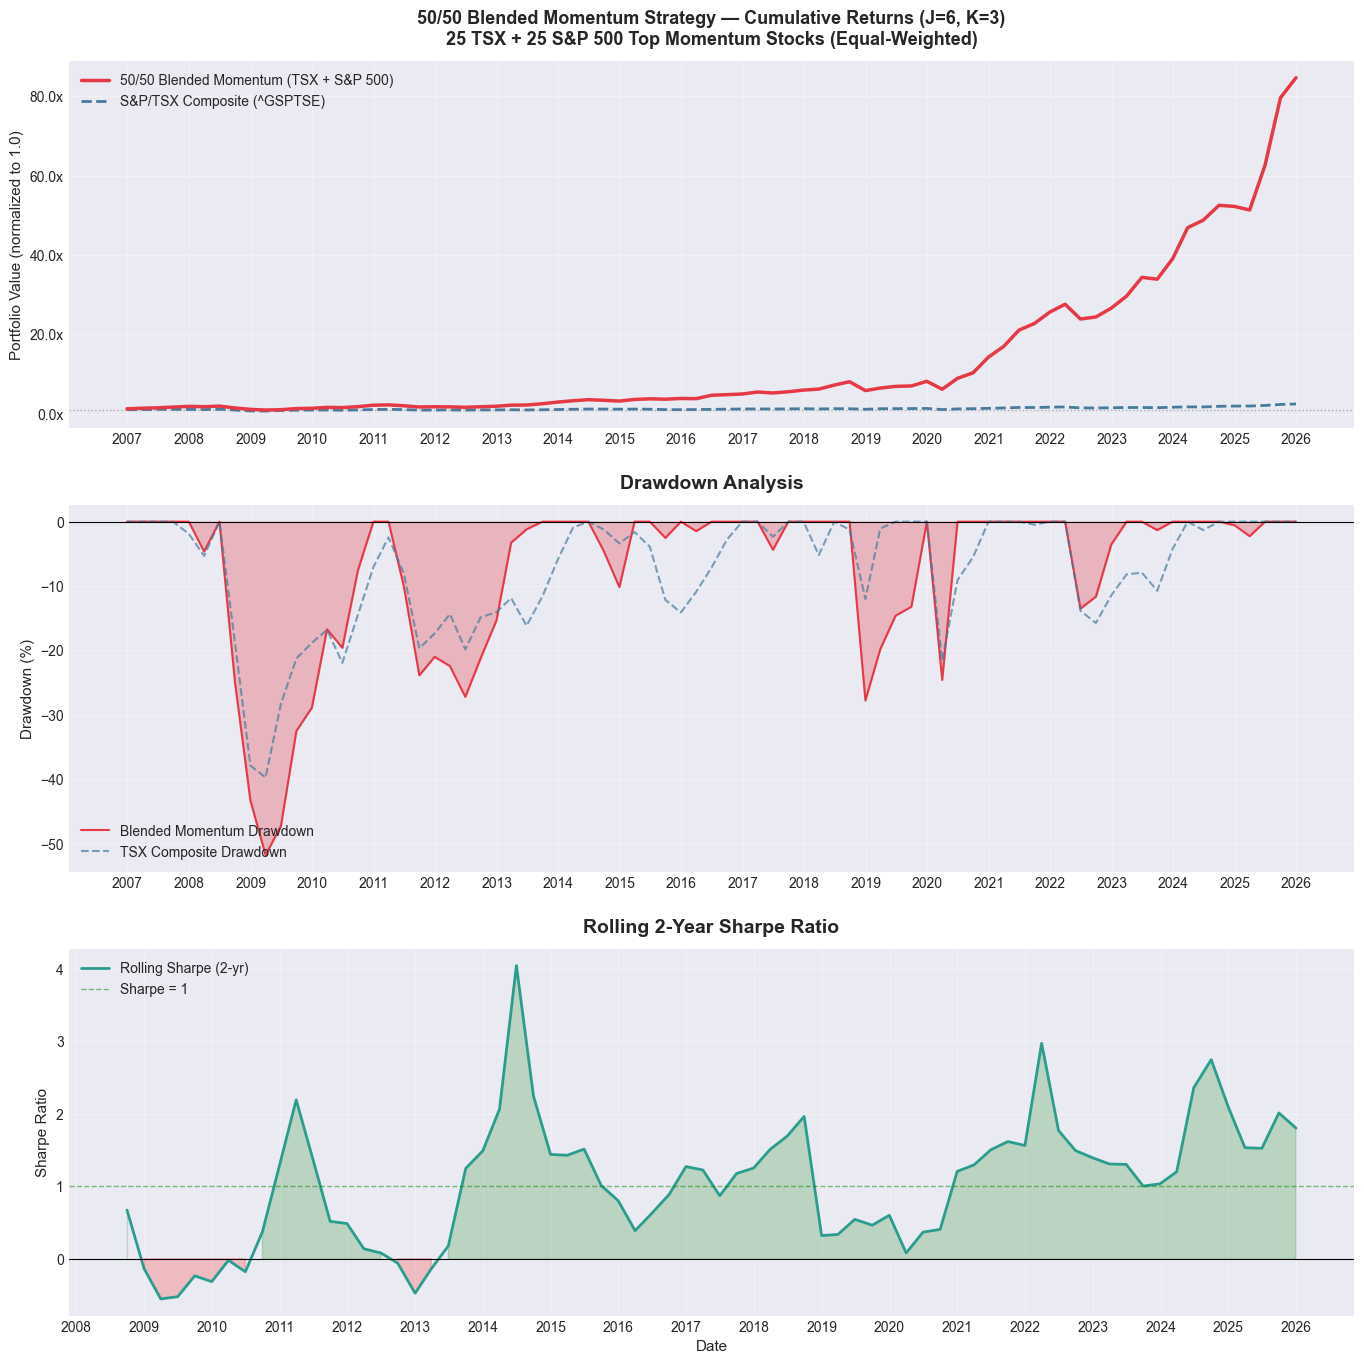

✓ Chart saved as 'blended_momentum_performance.png'


In [29]:
"""
VISUALIZATION
Three-panel chart: cumulative returns, drawdown, rolling 2-yr Sharpe.
"""

import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Panel 1 – Cumulative Returns
ax1 = axes[0]
cum_strategy = (1 + portfolio_returns).cumprod()
bm_start  = benchmark_prices.index.asof(portfolio_returns.index[0])
bm_rebase = (benchmark_prices / benchmark_prices.loc[bm_start]).reindex(portfolio_returns.index, method='ffill')

ax1.plot(cum_strategy.index, cum_strategy.values, lw=2.5, color='#E63946',
         label='50/50 Blended Momentum (TSX + S&P 500)', zorder=3)
ax1.plot(bm_rebase.index, bm_rebase.values, lw=2, color='#457B9D', ls='--',
         label='S&P/TSX Composite (^GSPTSE)', zorder=2)
ax1.axhline(1, color='gray', ls=':', alpha=0.6, lw=1)
ax1.set_title('50/50 Blended Momentum Strategy — Cumulative Returns (J=6, K=3)\n'
              '25 TSX + 25 S&P 500 Top Momentum Stocks (Equal-Weighted)',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Portfolio Value (normalized to 1.0)', fontsize=11)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}x'))

# Panel 2 – Drawdown
ax2 = axes[1]

def drawdown_series(cum_s):
    rm = cum_s.expanding().max()
    return (cum_s - rm) / rm * 100

dd_strat = drawdown_series(cum_strategy)
dd_bm    = drawdown_series(bm_rebase.dropna())

ax2.fill_between(dd_strat.index, dd_strat.values, 0, alpha=0.3, color='#E63946')
ax2.plot(dd_strat.index, dd_strat.values, lw=1.5, color='#E63946', label='Blended Momentum Drawdown')
ax2.plot(dd_bm.index,    dd_bm.values,    lw=1.5, color='#457B9D', ls='--', alpha=0.7, label='TSX Composite Drawdown')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Drawdown Analysis', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, alpha=0.3)

# Panel 3 – Rolling 2-year Sharpe
ax3 = axes[2]
window = 8
roll_sharpe = (
    (portfolio_returns.rolling(window).mean() * 4 - config.risk_free_rate)
    / (portfolio_returns.rolling(window).std() * np.sqrt(4))
)
ax3.plot(roll_sharpe.index, roll_sharpe.values, lw=2, color='#2A9D8F', label='Rolling Sharpe (2-yr)')
ax3.axhline(0, color='black', lw=0.8)
ax3.axhline(1, color='green', ls='--', alpha=0.5, lw=1, label='Sharpe = 1')
ax3.fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                 where=(roll_sharpe > 0), alpha=0.2, color='green')
ax3.fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                 where=(roll_sharpe < 0), alpha=0.2, color='red')
ax3.set_title('Rolling 2-Year Sharpe Ratio', fontsize=14, fontweight='bold', pad=12)
ax3.set_xlabel('Date', fontsize=11)
ax3.set_ylabel('Sharpe Ratio', fontsize=11)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout(pad=2.0)
plt.savefig('blended_momentum_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved as 'blended_momentum_performance.png'")

STEP 7: YEAR-BY-YEAR PERFORMANCE

Year        Blended    TSX Index      Alpha
---------------------------------------------
2007         49.73%         7.16%  ▲   42.57%
2008        -41.15%       -35.03%  ▼    6.12%
2009         25.46%        30.69%  ▼    5.23%
2010         57.25%        14.45%  ▲   42.81%
2011        -18.16%       -11.07%  ▼    7.09%
2012          7.16%         4.00%  ▲    3.16%
2013         56.05%         9.56%  ▲   46.50%
2014          8.41%         7.42%  ▲    0.99%
2015         20.84%       -11.09%  ▲   31.93%
2016         29.31%        17.51%  ▲   11.81%
2017         19.93%         6.03%  ▲   13.90%
2018         -2.20%       -11.64%  ▲    9.43%
2019         40.30%        19.13%  ▲   21.17%
2020         74.74%         2.17%  ▲   72.57%
2021         79.68%        21.74%  ▲   57.94%
2022          3.79%        -8.66%  ▲   12.45%
2023         46.65%         8.12%  ▲   38.53%
2024         33.85%        17.99%  ▲   15.87%
2025         62.14%        28.25%  ▲   33.89%
20

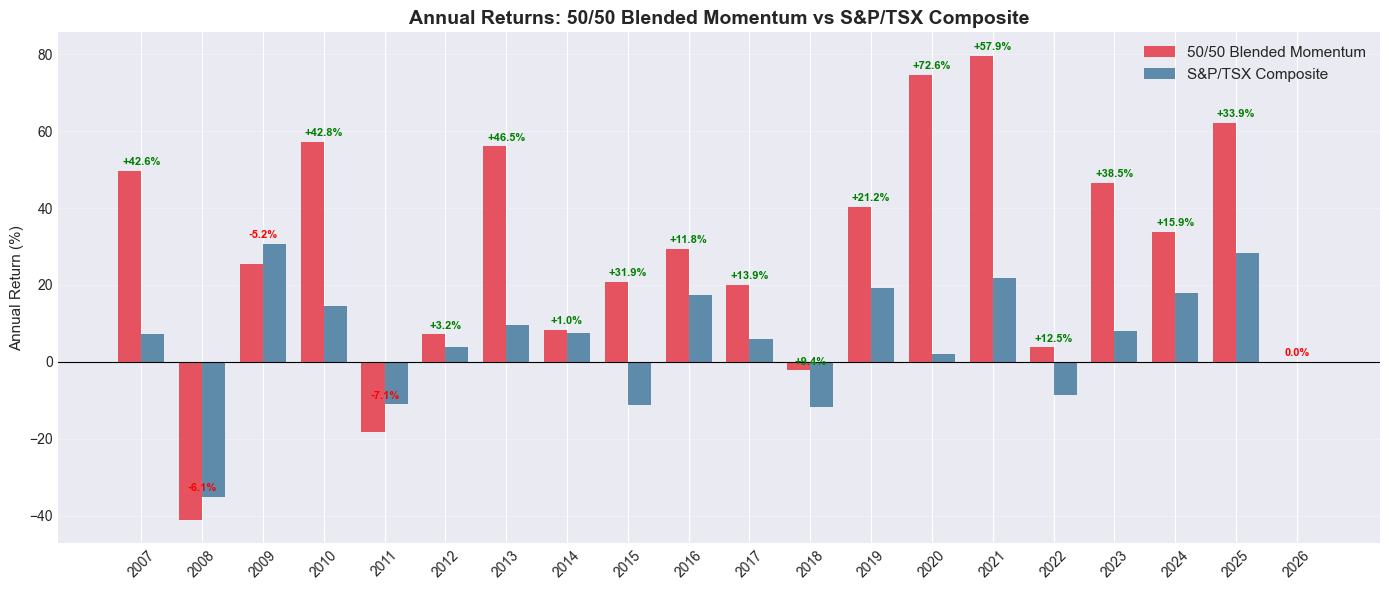


✓ Chart saved as 'blended_annual_returns.png'


In [30]:
"""
YEAR-BY-YEAR PERFORMANCE
Annual returns bar chart: 50/50 Blended Momentum vs TSX Composite.
"""

def annual_returns(s):
    return s.groupby(s.index.year).apply(lambda r: (1 + r).prod() - 1)

ann_strat = annual_returns(portfolio_returns)
ann_bm    = annual_returns(bm_aligned)

ann_cmp = pd.DataFrame({'50/50 Blended Momentum': ann_strat * 100,
                         'TSX Composite':           ann_bm * 100}).dropna()
ann_cmp['Alpha'] = ann_cmp['50/50 Blended Momentum'] - ann_cmp['TSX Composite']

print('=' * 80)
print('STEP 7: YEAR-BY-YEAR PERFORMANCE')
print('=' * 80)
print(f'\n{"Year":<6} {"Blended":>12} {"TSX Index":>12} {"Alpha":>10}')
print('-' * 45)
for year, row in ann_cmp.iterrows():
    arrow = '▲' if row['Alpha'] > 0 else '▼'
    print(f'{year:<6} {row["50/50 Blended Momentum"]:>11.2f}%  {row["TSX Composite"]:>11.2f}%  {arrow} {abs(row["Alpha"]):>7.2f}%')
print('-' * 45)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ann_cmp))
w = 0.38
ax.bar(x - w/2, ann_cmp['50/50 Blended Momentum'], w, color='#E63946', alpha=0.85, label='50/50 Blended Momentum')
ax.bar(x + w/2, ann_cmp['TSX Composite'],           w, color='#457B9D', alpha=0.85, label='S&P/TSX Composite')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ann_cmp.index.astype(str), rotation=45)
ax.set_title('Annual Returns: 50/50 Blended Momentum vs S&P/TSX Composite', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Return (%)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for i, (_, row) in enumerate(ann_cmp.iterrows()):
    color = 'green' if row['Alpha'] > 0 else 'red'
    label = f"+{row['Alpha']:.1f}%" if row['Alpha'] > 0 else f"{row['Alpha']:.1f}%"
    ax.text(i, max(row['50/50 Blended Momentum'], row['TSX Composite']) + 1.5,
            label, ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('blended_annual_returns.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Chart saved as 'blended_annual_returns.png'")

In [31]:
"""
PORTFOLIO COMPOSITION ANALYSIS
Which TSX stocks appear most frequently in momentum portfolios?
"""

all_holdings = [t for p in portfolios.values() for t in p]
top_stocks   = pd.Series(all_holdings).value_counts().head(25)

print('=' * 80)
print('STEP 8: PORTFOLIO COMPOSITION')
print('=' * 80)
print(f'\nTop 25 most frequently held stocks across {len(portfolios)} rebalances:')
print('-' * 50)
for ticker, cnt in top_stocks.items():
    pct = cnt / len(portfolios) * 100
    bar = '█' * int(pct / 4)
    print(f'  {ticker:<18} {cnt:>2}/{len(portfolios)} qtrs  {pct:5.1f}%  {bar}')

STEP 8: PORTFOLIO COMPOSITION

Top 25 most frequently held stocks across 79 rebalances:
--------------------------------------------------
  CEU.TO             18/79 qtrs   22.8%  █████
  NVDA               17/79 qtrs   21.5%  █████
  NFLX               17/79 qtrs   21.5%  █████
  AMD                16/79 qtrs   20.3%  █████
  TPL                15/79 qtrs   19.0%  ████
  AXON               15/79 qtrs   19.0%  ████
  DXCM               15/79 qtrs   19.0%  ████
  SHOP.TO            15/79 qtrs   19.0%  ████
  CLS.TO             14/79 qtrs   17.7%  ████
  OGC.TO             14/79 qtrs   17.7%  ████
  TVE.TO             14/79 qtrs   17.7%  ████
  BTE.TO             13/79 qtrs   16.5%  ████
  AG.TO              13/79 qtrs   16.5%  ████
  CS.TO              13/79 qtrs   16.5%  ████
  LUG.TO             13/79 qtrs   16.5%  ████
  WDO.TO             13/79 qtrs   16.5%  ████
  AYA.TO             13/79 qtrs   16.5%  ████
  BLDR               13/79 qtrs   16.5%  ████
  EFR.TO             12/79 qt

In [32]:
"""
FINAL SUMMARY
"""

print('=' * 80)
print('50/50 BLENDED MOMENTUM BACKTEST — FINAL SUMMARY')
print('=' * 80)
print()
print(f'Universe:        {config.universe}')
print(f'Strategy:        Momentum J={config.lookback_months}, K={config.holding_months}, Skip=1 month')
print(f'Portfolio Size:  {config.n_tsx} TSX + {config.n_sp500} S&P 500 = {config.n_positions} stocks (equal-weighted)')
print(f'Period:          {config.start_date.strftime("%Y-%m-%d")} → {config.end_date.strftime("%Y-%m-%d")}')
print(f'Capital:         $100,000 CAD')
print()
print(f'{"Metric":<28}  {"50/50 Blended":>16}  {"TSX Index":>16}')
print('-' * 65)
for metric in list(strategy_metrics.keys())[1:]:
    sv = strategy_metrics[metric]
    bv = benchmark_metrics.get(metric, 'N/A')
    print(f'  {metric:<26}  {sv:>16}  {bv:>16}')
print()
print('Key Observations:')
print('  • Constrained 50/50 split ensures geographic diversification every quarter.')
print('  • S&P 500 half provides USD exposure — natural hedge for Canadian investors.')
print('  • TSX half reduces FX transaction costs vs a pure S&P 500 portfolio.')
print('  • Benchmark (^GSPTSE) only reflects the TSX half — blended return will differ.')
print('  • Currency note: returns are in local currency (CAD for TSX, USD for S&P 500).')
print('=' * 80)

50/50 BLENDED MOMENTUM BACKTEST — FINAL SUMMARY

Universe:        S&P/TSX Composite (50%) + S&P 500 (50%)
Strategy:        Momentum J=6, K=3, Skip=1 month
Portfolio Size:  10 TSX + 10 S&P 500 = 20 stocks (equal-weighted)
Period:          2006-03-18 → 2026-03-18
Capital:         $100,000 CAD

Metric                           50/50 Blended         TSX Index
-----------------------------------------------------------------
  Total Return                        8368.85%           145.68%
  Annualized Return                     25.20%             4.72%
  Annualized Volatility                 26.32%            14.96%
  Sharpe Ratio                            0.84              0.11
  Sortino Ratio                           1.20              0.13
  Max Drawdown                         -51.75%           -39.72%
  Calmar Ratio                            0.49              0.12
  Win Rate                               72.2%             65.4%
  Avg Win                               12.56%          